# Missing Value Handling Using KNN Imputation

This notebook demonstrates how to load a dataset, check for missing values, apply **KNN-based imputation**, and convert the results back into a structured DataFrame for further analysis.


## 2. Load the Dataset (SalariesKNN.csv)

In this step, we load the dataset named **`SalariesKNN.csv`** using pandas.  
This dataset will be used to demonstrate missing value handling using KNN-based imputation.

In [11]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

df = pd.read_csv("SalariesKNN.csv")

## 3. Check for Missing (Null) Values

We examine the dataset to identify missing (null) values.

- Display whether null values exist in the dataset  
- Check the total number of missing values in each column  

This step helps determine whether imputation is required.

In [12]:
df.isnull()

,Age,Salary,Experience,Class
0,False,False,False,False
1,False,True,False,False
2,False,False,True,False
3,True,False,False,False
4,False,False,False,False
5,False,False,False,False
6,False,False,True,False
7,True,False,False,False
8,False,True,False,False
9,False,False,False,False


## 4. Extract All Features

All feature columns are extracted from the dataset and stored in a separate variable.

- This step prepares the data for applying the KNN imputation algorithm  
- The extracted features are stored in a variable (e.g., `X`)  

In [13]:
cols = ['Age', 'Salary', 'Experience']
cols

['Age', 'Salary', 'Experience']

**5**. The **KNNImputer** is applied to handle missing values.

- The imputer identifies the *K nearest neighbors* for each missing value  
- Missing values are replaced based on the average of neighboring values  
- The `fit_transform()` method is used to learn from the data and apply imputation  

In [14]:
from sklearn.model_selection import train_test_split

# Select feature columns and target (note: 'Class' with capital C in the CSV)
X = df[cols]
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

imputer = KNNImputer(n_neighbors=2)

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

## 6. Convert Imputed Data Back to a DataFrame

After applying KNN imputation, the transformed data is converted back into a pandas DataFrame.

- Column names are preserved using `X.columns`  
- This ensures the structure of the original dataset remains intact  

The resulting DataFrame contains no missing values and is ready for further analysis or machine learning

In [15]:
# Convert imputed numpy arrays back to pandas DataFrames (preserve column names)
X_train_df = pd.DataFrame(X_train, columns=cols)
X_test_df = pd.DataFrame(X_test, columns=cols)

# Preview the imputed training features
X_train_df.head()

,Age,Salary,Experience
0,30.0,55.0,5.0
1,25.0,50.0,2.0
2,37.5,120.0,12.0
3,32.0,60.0,6.0
4,35.0,70.0,7.0


In [16]:
X_train_df.isnull()

,Age,Salary,Experience
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False


## 7. Visualization of Results (KNN Imputation)

After applying **KNN-based imputation**, visualizations are created to evaluate the effect of this technique on the dataset.

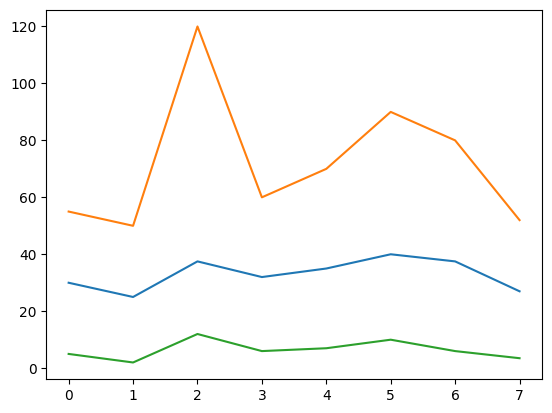

In [9]:
plt.plot(X_train_df)
plt.show()